<h2 style="text-align:center;font-size:200%;;">Лабораторная 1 по дисциплине СОБД</h2>
<h3  style="text-align:center;"><a href="https://www.kaggle.com/datasets/pigment/big-sales-data">Датасет 2.8ГБ: Books_rating</a></h3>

# **1. Инициализация pyspark и dataframe** <a class="anchor" id="1"></a>

In [1]:
# Import other modules not related to PySpark
import os
import sys
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import math
from IPython.core.interactiveshell import InteractiveShell
from datetime import *
import statistics as stats
# This helps auto print out the items without explixitly using 'print'
InteractiveShell.ast_node_interactivity = "all" 
%matplotlib inline

In [1]:
# Import PySpark related modules
import pyspark
from pyspark.rdd import RDD
from pyspark.sql import Row
from pyspark.sql import DataFrame
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext
from pyspark.sql import functions
from pyspark.sql.functions import col, count, when, isnan, isnull, mean, stddev, regexp_replace, expr, col, trim
from pyspark.sql.types import *

MAX_MEMORY = '15G'
# Initialize a spark session.
conf = pyspark.SparkConf().setMaster("local[*]") \
        .set('spark.executor.heartbeatInterval', 10000) \
        .set('spark.network.timeout', 10000) \
        .set("spark.core.connection.ack.wait.timeout", "3600") \
        .set("spark.executor.memory", MAX_MEMORY) \
        .set("spark.driver.memory", MAX_MEMORY)

# Инициализация Spark
def init_spark():
    return SparkSession.builder \
        .appName("BooksRatingAnalysis") \
        .getOrCreate()

spark = init_spark()

# Загрузка данных
filename_data1 = 'data/Books_rating.csv'
filename_data2 = 'data/books_data.csv'

df1 = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(filename_data1)

df2 = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(filename_data2)

df = df1.join(df2, "Title", "inner")

print("Размер датасета:", (df.count(), len(df.columns)))

Размер датасета: (2999829, 19)


# **2. Обзор Датасета** <a class="anchor" id="2"></a>

In [2]:
df.printSchema()

print("\nКоличество записей по типам данных:")
from pyspark.sql.types import NumericType, StringType
for field in df.schema.fields:
    if isinstance(field.dataType, NumericType):
        data_type = "Числовой"
    elif isinstance(field.dataType, StringType):
        data_type = "Строковый"
    else:
        data_type = "Другой"
    print(f"{field.name}: {data_type} ({field.dataType})")

root
 |-- Title: string (nullable = true)
 |-- Id: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)
 |-- description: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- ratingsCount: string (nullable = true)


Количество записей по типам данных:
Title: Строковый (StringType())
Id: Строковый (StringType())
Price: Строковый (StringType())
User_id: Строковый (StringType())
profileName: Строковый (StringType())
re

In [8]:
print('Описание Датафрейма (только строковые и числовые столбцы):')
df.describe().toPandas()

print(f'Всего {df.count()} строк, Вывод первых 2 строк данных:')
df.limit(2).toPandas()

Описание Датафрейма (только строковые и числовые столбцы):


,summary,Id,Title,Price,User_id,profileName,review_helpfulness,review_score,review_time,review_summary,review_text,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio
0,count,1280981,2999792,480731,2437750,2437800,2999633,2981936,2995268,2999935,2999957,2981941,2981941,3000000
1,mean,8.750887636698718E8,2012.796651763537,21.767951161877054,18.29299003322259,NaN,3.285048033703448E8,1656.860421970827,1.1270533345949814E9,Infinity,9.95368319174848E8,3199.5244332466673,3201.616763711958,0.48891735013897314
2,stddev,5.161812590603045E8,1536.7533549608797,26.21155241772817,21.99284402625621,NaN,5.46938050416698E8,1427549.9863179324,1.6715719402140123E8,NaN,4.227222142880359E8,1964277.0624294658,1964277.0590624036,0.4312941250821434
3,min,1047604,""""""" Film technique",1.0,""""" Film acting """"""",,"#1 Bestse...""",1.0,-1,"""""The Child Manuela"""" chronicles the tragic l...",The Tao of Muhammad Ali is the most beautifu...,0,0,0.0
4,max,2090337427,you can do anything with crepes,995.0,AZZZZW74AAX75,~~~~~~~,xo,1.295568E9,1362355200,~~~~~~~~~~~~~~~~~~~~~~~~~~,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,1348444800,1348444800,3.0


Всего 3000000 строк, Вывод первых 2 строк данных:


,Id,Title,Price,User_id,profileName,review_helpfulness,review_score,review_time,review_summary,review_text,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"""Jim of Oz """"jim-of-oz""""""",7/7,4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...,7,7,1.0
1,826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,1095724800,Really Enjoyed It,I don't care much for Dr. Seuss but after read...,10,10,1.0


# **3. Преобразование данных** <a class="anchor" id="3"></a>

In [28]:
# Преобразуем числовые колонки
df = df \
    .withColumn("Id", col("Id").cast("int")) \
    .withColumn("Price", col("Price").cast("double")) \
    .withColumn("review/score", col("review/score").cast("double")) \
    .withColumn("review/time", col("review/time").cast("int"))

# Извлекаем числовую часть из review/helpfulness
df = df.withColumn(
    "helpfulness_numerator", 
    regexp_replace(col("review/helpfulness"), r"(\d+)/\d+", "$1").cast("int")
).withColumn(
    "helpfulness_denominator", 
    regexp_replace(col("review/helpfulness"), r"\d+/(\d+)", "$1").cast("int")
).withColumn(
    "helpfulness_ratio", 
    when(col("helpfulness_denominator") > 0, 
         col("helpfulness_numerator") / col("helpfulness_denominator"))
    .otherwise(0.0)
)

# Заменяем имена
df = df \
    .withColumnRenamed("review/score", "review_score") \
    .withColumnRenamed("review/time", "review_time") \
    .withColumnRenamed("review/helpfulness", "review_helpfulness") \
    .withColumnRenamed("review/summary", "review_summary") \
    .withColumnRenamed("review/text", "review_text")

print("Схема после преобразования:")
df.printSchema()

Схема после преобразования:
root
 |-- Id: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_text: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)



# **4. Анализ пропущенных значений** <a class="anchor" id="3"></a>

In [6]:
print('Обзор')
pd.DataFrame(df.dtypes, columns = ['Column Name','Data type'])

Обзор


,Column Name,Data type
0,Id,int
1,Title,string
2,Price,double
3,User_id,string
4,profileName,string
5,review_helpfulness,string
6,review_score,double
7,review_time,int
8,review_summary,string
9,review_text,string


In [30]:

# Простой анализ всех колонок
missing_results = {}

for column in df.columns:
    # Для всех колонок проверяем основные проблемы
    missing_count = df.filter(
        col(column).isNull() | 
        isnan(col(column)) |
        (trim(col(column)) == "") |  # пустые строки
        (trim(col(column)).isin(["null", "NULL", "None", "none"])) |  # строки "null"
        (col(column) == 0)  # нули в числовых колонках
    ).count()
    
    missing_results[column] = missing_count

# Вывод результатов
total_rows = df.count()
print(f"Всего строк в датасете: {total_rows}")

print("\nПРОБЛЕМНЫЕ ЗНАЧЕНИЯ ПО КОЛОНКАМ:")
print("=" * 60)
for column, count_val in missing_results.items():
    if count_val > 0:  # Показываем только колонки с проблемами
        percentage = (count_val / total_rows) * 100
        print(f"  {column:<20}: {count_val:>6} значений ({percentage:>6.2f}%)")

# Создаем очищенный DataFrame
print("\nОЧИСТКА ДАННЫХ...")

df_clean = df

# Удаляем строки с проблемами в ключевых полях
df_clean = df_clean.dropna(subset=["Id", "review_score"])

# Заполняем пропуски в Price
df_clean = df_clean.fillna({"Price": 0.0})

# Заменяем пустые строки в текстовых полях
text_columns = ["Title", "User_id", "profileName", "review_summary", "review_text"]
for col_name in text_columns:
    if col_name in df_clean.columns:
        df_clean = df_clean.withColumn(
            col_name, 
            when(
                (trim(col(col_name)) == "") | 
                (col(col_name).isNull()) |
                (trim(col(col_name)).isin(["null", "NULL", "None", "none"])),
                "Не указано"
            ).otherwise(col(col_name))
        )

print(f"Размер после очистки: {df_clean.count()} строк")
print(f"Удалено строк: {df.count() - df_clean.count()}")

print("\nСхема после очистки:")
df_clean.printSchema()

Всего строк в датасете: 3000000

ПРОБЛЕМНЫЕ ЗНАЧЕНИЯ ПО КОЛОНКАМ:
  Id                  : 1719019 значений ( 57.30%)
  Title               :    211 значений (  0.01%)
  Price               : 2519269 значений ( 83.98%)
  User_id             : 562250 значений ( 18.74%)
  profileName         : 562392 значений ( 18.75%)
  review_helpfulness  :    367 значений (  0.01%)
  review_score        :  18064 значений (  0.60%)
  review_time         :   4732 значений (  0.16%)
  review_summary      :    709 значений (  0.02%)
  review_text         :     46 значений (  0.00%)
  helpfulness_numerator: 1122483 значений ( 37.42%)
  helpfulness_denominator: 899473 значений ( 29.98%)
  helpfulness_ratio   : 1122483 значений ( 37.42%)

ОЧИСТКА ДАННЫХ...
Размер после очистки: 1272673 строк
Удалено строк: 1727327

Схема после очистки:
root
 |-- Id: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: double (nullable = false)
 |-- User_id: string (nullable = true)
 |-- profileName: stri

# **5. Статистические показатели** <a class="anchor" id="3"></a>

In [13]:
# Базовая статистика для числовых колонок
numeric_cols = ["Price", "review_score", "review_time", "helpfulness_ratio"]
print("Базовая статистика:")
df_clean.describe(numeric_cols).show()

# Детальная статистика с квартилями
for col_name in numeric_cols:
    print(f"\nДетальная статистика для {col_name}:")
    stats = df_clean.select(
        mean(col_name).alias("mean"),
        stddev(col_name).alias("std"),
        *[expr(f"percentile_approx({col_name}, {q})").alias(f"q{int(q*100)}") 
          for q in [0.25, 0.5, 0.75]]
    )
    stats.show()

Базовая статистика:
+-------+-----------------+------------------+--------------------+-------------------+
|summary|            Price|      review_score|         review_time|  helpfulness_ratio|
+-------+-----------------+------------------+--------------------+-------------------+
|  count|          1272673|           1272673|             1272657|            1272673|
|   mean|7.143797794091918| 4.201220777057421|1.1299039200186617E9| 0.5250668946774928|
| stddev|18.34463604008265|1.2508410213023922|1.4460997792643583E8|0.42996838478461274|
|    min|              0.0|               1.0|                  -1|                0.0|
|    max|            995.0|             327.0|          1362355200|                2.0|
+-------+-----------------+------------------+--------------------+-------------------+


Детальная статистика для Price:
+-----------------+-----------------+---+---+-----+
|             mean|              std|q25|q50|  q75|
+-----------------+-----------------+---+---+-----

# **6. Анализ и обработка выбросов** <a class="anchor" id="3"></a>

In [14]:
def detect_outliers(column_name):
    """Обнаружение выбросов с помощью IQR метода"""
    quantiles = df_clean.approxQuantile(column_name, [0.25, 0.75], 0.05)
    Q1, Q3 = quantiles[0], quantiles[1]
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean.filter(
        (col(column_name) < lower_bound) | (col(column_name) > upper_bound)
    )
    
    print(f"Выбросы в {column_name}:")
    print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Количество выбросов: {outliers.count()}")
    print(f"  Процент выбросов: {(outliers.count() / df_clean.count()) * 100:.2f}%")
    
    return lower_bound, upper_bound

# Анализ выбросов для числовых колонок
for col_name in numeric_cols:
    if col_name != "helpfulness_ratio":  # Пропускаем ratio т.к. он уже нормализован
        detect_outliers(col_name)

# Обработка выбросов в Price (ограничение сверху)
price_upper_bound = 1000  # Предполагаем, что цена больше 1000 - выброс
df_clean = df_clean.withColumn(
    "Price", 
    when(col("Price") > price_upper_bound, price_upper_bound)
    .otherwise(col("Price"))
)

Выбросы в Price:
  Границы: [-11.98, 19.98]
  Количество выбросов: 129973
  Процент выбросов: 10.21%


(-11.985, 19.975)

Выбросы в review_score:
  Границы: [2.50, 6.50]
  Количество выбросов: 155182
  Процент выбросов: 12.19%


(2.5, 6.5)

Выбросы в review_time:
  Границы: [654004800.00, 1585396800.00]
  Количество выбросов: 10
  Процент выбросов: 0.00%


(654004800.0, 1585396800.0)

# **7. Визуализация распределений** <a class="anchor" id="3"></a>

(array([ 678.,    0.,  509.,    0.,    0.,  810.,    0., 1980.,    0.,
        6023.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

Text(0.5, 1.0, 'Распределение оценок (review_score)')

Text(0.5, 0, 'Оценка')

Text(0, 0.5, 'Частота')

(array([6.703e+03, 1.880e+02, 1.070e+03, 7.050e+02, 3.960e+02, 3.400e+02,
        1.020e+02, 1.990e+02, 7.800e+01, 4.300e+01, 3.800e+01, 3.500e+01,
        1.800e+01, 3.000e+00, 1.000e+01, 2.000e+00, 9.000e+00, 9.000e+00,
        1.100e+01, 5.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 4.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 1.000e+01, 2.000e+00,
        9.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([  0. ,   4.2,   8.4,  12.6,  16.8,  21. ,  25.2,  29.4,  33.6,
         37.8,  42. ,  46.2,  50.4,  54.6,  58.8,  63. ,  67.2,  71.4,
         75.6,  79.8,  84. ,  88.2,  92.4,  96.6, 100.8, 105. , 109.2,
        113.4, 117.6, 121.8, 126. , 130.2, 134.4, 138.6, 142.8, 147. ,
        151.2, 155.4, 159.6, 163.8, 168. , 172.2, 176.4, 180.6, 184.8,
        189. , 193.2,

...

Text(0, 0.5, 'Частота')

(array([3.036e+03, 1.200e+02, 2.190e+02, 2.540e+02, 1.480e+02, 7.600e+02,
        4.930e+02, 4.740e+02, 7.360e+02, 5.550e+02, 3.204e+03, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]),
 <BarContainer object of 20 artists>)

Text(0.5, 1.0, 'Распределение коэффициента полезности отзывов')

Text(0.5, 0, 'Helpfulness Ratio')

Text(0, 0.5, 'Частота')

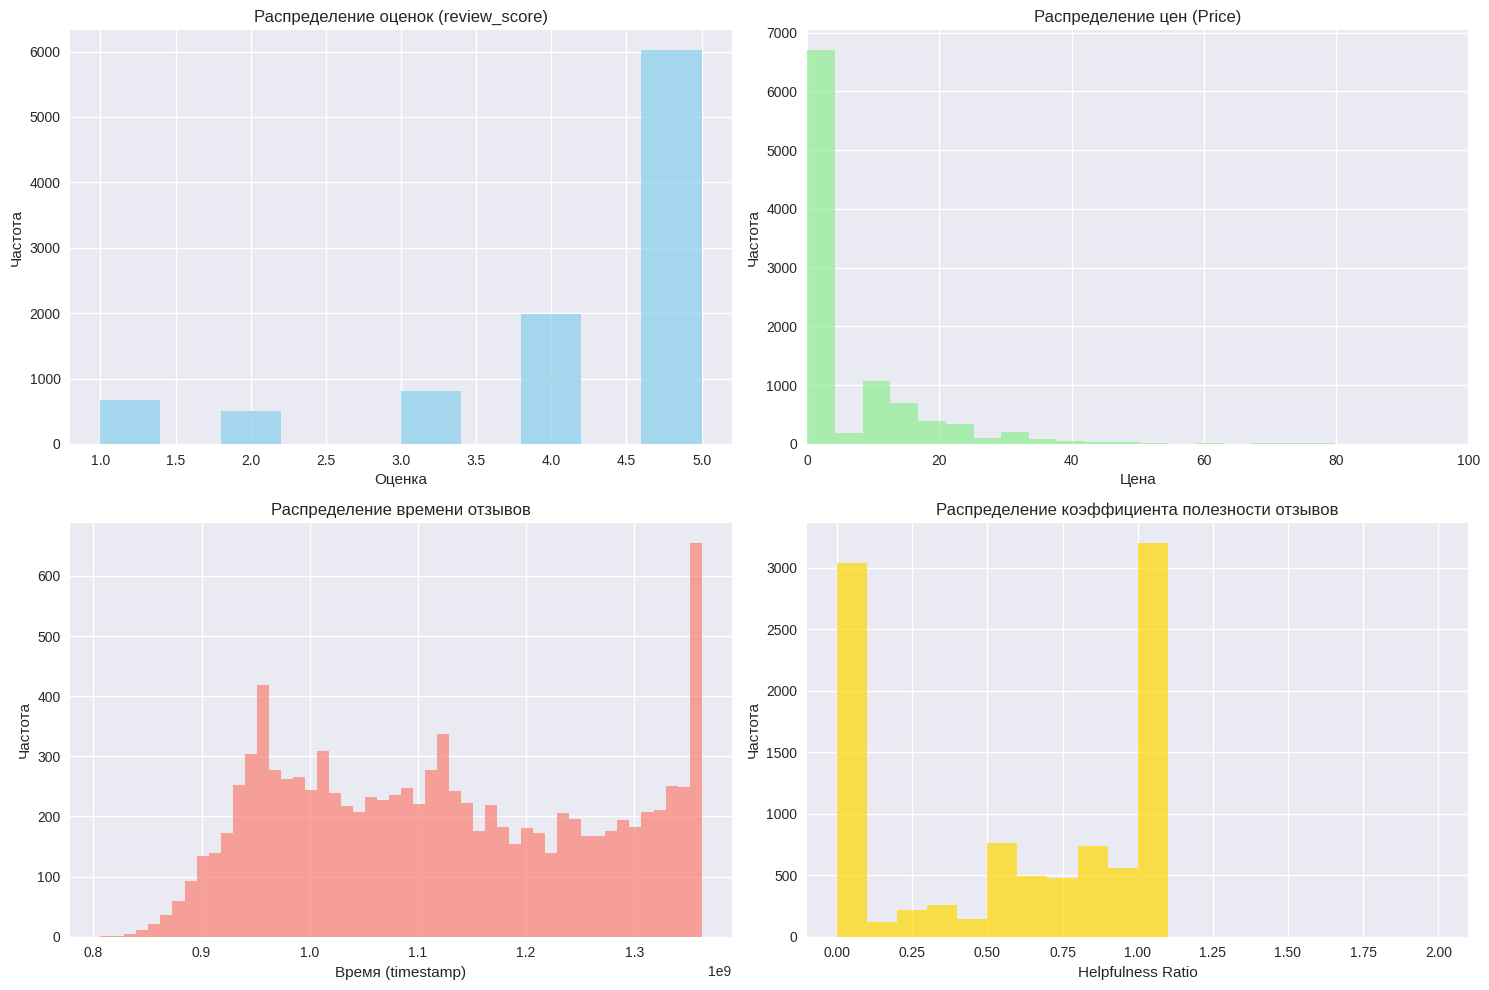

<Figure size 1200x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Боксплот числовых признаков')

([0, 1, 2],
 [Text(0, 0, 'Price'),
  Text(1, 0, 'review_score'),
  Text(2, 0, 'helpfulness_ratio')])

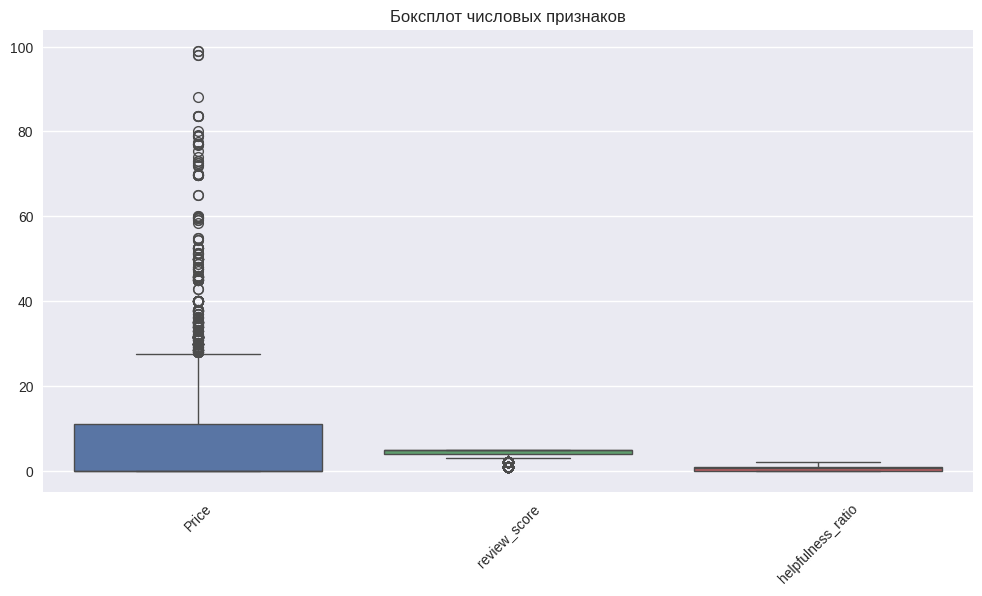

In [15]:
# Собираем данные для визуализации (первые 10000 строк для производительности)
sample_pd = df_clean.limit(10000).toPandas()

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Распределение оценок (review/score)
axes[0, 0].hist(sample_pd['review_score'], bins=10, alpha=0.7, color='skyblue')
axes[0, 0].set_title('Распределение оценок (review_score)')
axes[0, 0].set_xlabel('Оценка')
axes[0, 0].set_ylabel('Частота')

# Распределение цен
axes[0, 1].hist(sample_pd['Price'], bins=50, alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Распределение цен (Price)')
axes[0, 1].set_xlabel('Цена')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_xlim(0, 100)  # Ограничиваем для лучшей визуализации

# Распределение времени отзывов
axes[1, 0].hist(sample_pd['review_time'], bins=50, alpha=0.7, color='salmon')
axes[1, 0].set_title('Распределение времени отзывов')
axes[1, 0].set_xlabel('Время (timestamp)')
axes[1, 0].set_ylabel('Частота')

# Распределение коэффициента полезности
axes[1, 1].hist(sample_pd['helpfulness_ratio'], bins=20, alpha=0.7, color='gold')
axes[1, 1].set_title('Распределение коэффициента полезности отзывов')
axes[1, 1].set_xlabel('Helpfulness Ratio')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Боксплот для числовых признаков
plt.figure(figsize=(12, 6))
numeric_data = sample_pd[['Price', 'review_score', 'helpfulness_ratio']]
numeric_data = numeric_data[numeric_data['Price'] < 100]  # Убираем крайние выбросы для визуализации
sns.boxplot(data=numeric_data)
plt.title('Боксплот числовых признаков')
plt.xticks(rotation=45)
plt.show()

# **8. Анализ корреляций** <a class="anchor" id="3"></a>

1. ПОДГОТОВКА ДАННЫХ ДЛЯ КОРРЕЛЯЦИОННОГО АНАЛИЗА:
Текущий размер данных: 1272673
  Price: 0 NULL/NaN после очистки
  review_score: 0 NULL/NaN после очистки
  review_time: 0 NULL/NaN после очистки
  helpfulness_ratio: 0 NULL/NaN после очистки
Размер данных для корреляционного анализа: 1272657 строк
Удалено строк: 16

2. РАСЧЕТ ПОПАРНЫХ КОРРЕЛЯЦИЙ:
  Ошибка при расчете Price - review_score: name 'corr' is not defined
  Ошибка при расчете Price - review_time: name 'corr' is not defined
  Ошибка при расчете Price - helpfulness_ratio: name 'corr' is not defined
  Ошибка при расчете review_score - review_time: name 'corr' is not defined
  Ошибка при расчете review_score - helpfulness_ratio: name 'corr' is not defined
  Ошибка при расчете review_time - helpfulness_ratio: name 'corr' is not defined

3. СОЗДАНИЕ МАТРИЦЫ КОРРЕЛЯЦИЙ:

4. ВИЗУАЛИЗАЦИЯ МАТРИЦЫ КОРРЕЛЯЦИЙ:


<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Матрица корреляций Пирсона между числовыми признаками')

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'Price'),
  Text(1.5, 0, 'review_score'),
  Text(2.5, 0, 'review_time'),
  Text(3.5, 0, 'helpfulness_ratio')])

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'Price'),
  Text(0, 1.5, 'review_score'),
  Text(0, 2.5, 'review_time'),
  Text(0, 3.5, 'helpfulness_ratio')])

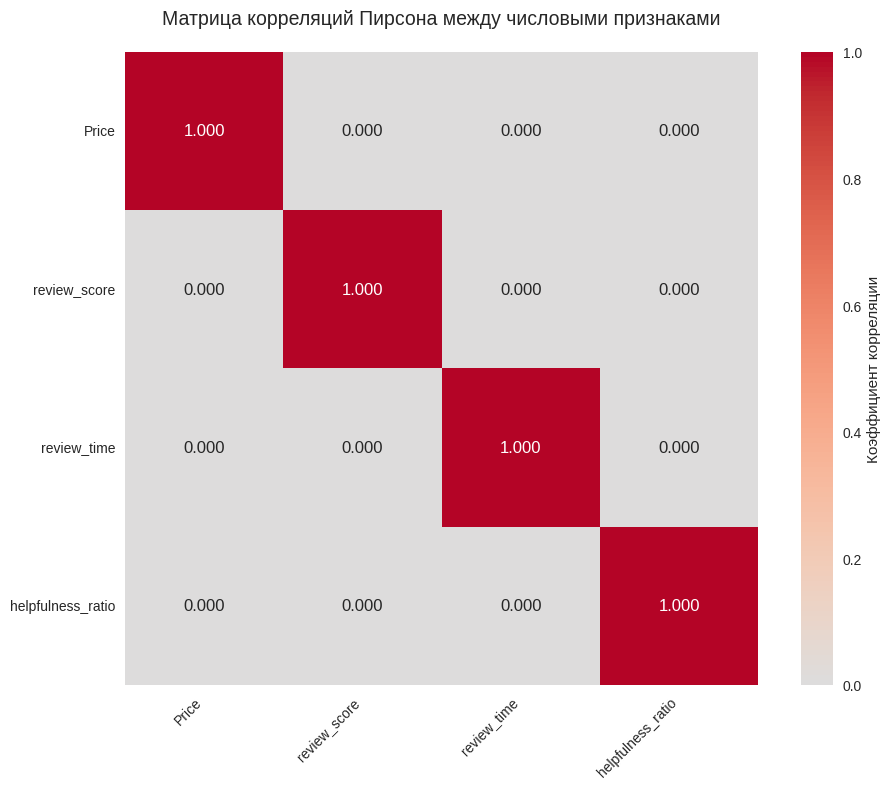


5. ИНТЕРПРЕТАЦИЯ КОРРЕЛЯЦИЙ:
САМЫЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ:
  Price           - review_score        : ⚪ ОЧЕНЬ СЛАБАЯ отрицательная ↘️ (0.000)
  Price           - review_time         : ⚪ ОЧЕНЬ СЛАБАЯ отрицательная ↘️ (0.000)
  Price           - helpfulness_ratio   : ⚪ ОЧЕНЬ СЛАБАЯ отрицательная ↘️ (0.000)

6. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОРРЕЛЯЦИЙ:
Объем выборки для корреляционного анализа: 1272657 строк
Объем выборки достаточен для надежных корреляционных выводов

7. ОСНОВНЫЕ ВЫВОДЫ:
Ключевые наблюдения:
  • Сильных корреляций между числовыми признаками не обнаружено
  • Все признаки ведут себя относительно независимо


In [33]:
# Определяем числовые колонки для анализа
numeric_features = ["Price", "review_score", "review_time", "helpfulness_ratio"]

# 1. ТЩАТЕЛЬНАЯ ОЧИСТКА ДАННЫХ ДЛЯ КОРРЕЛЯЦИЙ
print("1. ПОДГОТОВКА ДАННЫХ ДЛЯ КОРРЕЛЯЦИОННОГО АНАЛИЗА:")

# Проверяем текущее состояние
print("Текущий размер данных:", df_clean.count())

# Удаляем ВСЕ строки с NULL в числовых колонках
df_corr = df_clean.dropna(subset=numeric_features)

# Дополнительно: проверяем на бесконечности и другие аномалии
for col_name in numeric_features:
    # Подсчет оставшихся проблем
    null_count = df_corr.filter(col(col_name).isNull() | isnan(col(col_name))).count()
    print(f"  {col_name}: {null_count} NULL/NaN после очистки")

print(f"Размер данных для корреляционного анализа: {df_corr.count()} строк")
print(f"Удалено строк: {df_clean.count() - df_corr.count()}")

# 2. РАСЧЕТ ПОПАРНЫХ КОРРЕЛЯЦИЙ
print("\n2. РАСЧЕТ ПОПАРНЫХ КОРРЕЛЯЦИЙ:")

correlation_results = []
print("=" * 60)

for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        col1 = numeric_features[i]
        col2 = numeric_features[j]
        
        # Рассчитываем корреляцию
        try:
            correlation = df_corr.select(corr(col1, col2)).collect()[0][0]
            if correlation is None:
                correlation = 0.0  # Если корреляция не может быть вычислена
                
            correlation_results.append((col1, col2, correlation))
            print(f"  {col1:20} - {col2:20}: {correlation:7.3f}")
            
        except Exception as e:
            print(f"  Ошибка при расчете {col1} - {col2}: {e}")
            correlation_results.append((col1, col2, 0.0))

print("=" * 60)

# 3. СОЗДАНИЕ МАТРИЦЫ КОРРЕЛЯЦИЙ
print("\n3. СОЗДАНИЕ МАТРИЦЫ КОРРЕЛЯЦИЙ:")

# Создаем матрицу корреляций
corr_matrix = np.eye(len(numeric_features))  # Единичная матрица (диагональ = 1)

# Заполняем матрицу значениями корреляций
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        if i == j:
            corr_matrix[i, j] = 1.0  # Корреляция с самой собой
        elif i < j:
            # Находим соответствующую корреляцию в результатах
            for col1, col2, corr_val in correlation_results:
                if (col1 == numeric_features[i] and col2 == numeric_features[j]):
                    corr_matrix[i, j] = corr_val
                    corr_matrix[j, i] = corr_val
                    break

# 4. ВИЗУАЛИЗАЦИЯ
print("\n4. ВИЗУАЛИЗАЦИЯ МАТРИЦЫ КОРРЕЛЯЦИЙ:")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            xticklabels=numeric_features, 
            yticklabels=numeric_features,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.3f', 
            square=True,
            cbar_kws={'label': 'Коэффициент корреляции'},
            annot_kws={'size': 12})

plt.title('Матрица корреляций Пирсона между числовыми признаками', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
print("\n5. ИНТЕРПРЕТАЦИЯ КОРРЕЛЯЦИЙ:")
print("=" * 70)

# Сортируем корреляции по силе (по абсолютному значению)
strong_correlations = sorted(correlation_results, key=lambda x: abs(x[2]), reverse=True)

print("САМЫЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ:")
for col1, col2, corr_val in strong_correlations[:3]:  # Топ-3
    abs_corr = abs(corr_val)
    if abs_corr > 0.7:
        strength = "🔴 ОЧЕНЬ СИЛЬНАЯ"
    elif abs_corr > 0.5:
        strength = "🟡 СИЛЬНАЯ"
    elif abs_corr > 0.3:
        strength = "🟢 УМЕРЕННАЯ"
    elif abs_corr > 0.1:
        strength = "🔵 СЛАБАЯ"
    else:
        strength = "⚪ ОЧЕНЬ СЛАБАЯ"
    
    direction = "положительная ↗️" if corr_val > 0 else "отрицательная ↘️"
    print(f"  {col1:15} - {col2:20}: {strength} {direction} ({corr_val:.3f})")

print("=" * 70)

# 6. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ
print("\n6. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОРРЕЛЯЦИЙ:")
print(f"Объем выборки для корреляционного анализа: {df_corr.count()} строк")

# Эмпирическое правило для статистической значимости
sample_size = df_corr.count()
if sample_size > 100:
    print("Объем выборки достаточен для надежных корреляционных выводов")
else:
    print("Внимание: небольшой объем выборки может влиять на надежность корреляций")

# 7. ВЫВОДЫ
print("\n7. ОСНОВНЫЕ ВЫВОДЫ:")

# Анализ самых интересных корреляций
print("Ключевые наблюдения:")
for col1, col2, corr_val in strong_correlations:
    abs_corr = abs(corr_val)
    if abs_corr > 0.3:  # Показываем только умеренные и сильные корреляции
        if corr_val > 0:
            relationship = "положительная связь"
        else:
            relationship = "отрицательная связь"
        print(f"  • {col1} и {col2} имеют {relationship} ({corr_val:.3f})")

if not any(abs(c[2]) > 0.3 for c in strong_correlations):
    print("  • Сильных корреляций между числовыми признаками не обнаружено")
    print("  • Все признаки ведут себя относительно независимо")

# **9. Анализ текста** <a class="anchor" id="3"></a>

In [36]:
from pyspark.sql.functions import length

# Анализ длины отзывов
df_clean = df_clean.withColumn("review_length", length(col("review_text")))

# Статистика по длине отзывов
print("Статистика по длине текста отзывов:")
df_clean.describe("review_length").show()

# Топ самых активных пользователей
print("Топ-10 самых активных пользователей:")
df_clean.groupBy("User_id").count().orderBy("count", ascending=False).show(10)

# Распределение по оценкам
print("Распределение отзывов по оценкам:")
df_clean.groupBy("review_score").count().orderBy("review_score").show()

Статистика по длине текста отзывов:
+-------+-----------------+
|summary|    review_length|
+-------+-----------------+
|  count|          1272673|
|   mean|605.8601086060598|
| stddev|621.5811443232944|
|    min|                1|
|    max|            32551|
+-------+-----------------+

Топ-10 самых активных пользователей:
+--------------+------+
|       User_id| count|
+--------------+------+
|    Не указано|223478|
|A14OJS0VWMOSWO|  4090|
|   AFVQZQ8PW0L|  2184|
|A1D2C0WDCSHUWZ|  1326|
|A1X8VZWTOG8IS6|   623|
| AHD101501WCN1|   619|
|A1K1JW1C5CUSUZ|   595|
|A2VKWLCNZF4ZVB|   527|
|A1M8PP7MLHNBQB|   497|
|A3M174IC0VXOS2|   473|
+--------------+------+
only showing top 10 rows

Распределение отзывов по оценкам:
+------------+------+
|review_score| count|
+------------+------+
|         1.0| 88902|
|         2.0| 66264|
|         3.0|107339|
|         4.0|248053|
|         5.0|762099|
|       19.95|    15|
|       327.0|     1|
+------------+------+

